In [1]:
import glob
import os
import xarray as xa
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
from scipy.interpolate import RectBivariateSpline
from scipy.stats import pearsonr
from scipy.ndimage import convolve

import cartopy.crs as ccrs
from cartopy.feature import LAND, COASTLINE
import cmocean.cm as ocm

from subprocess import call
import shutil


In [17]:
#wget https://n5eil01u.ecs.nsidc.org/AMSA/AU_SI12.001/2016.01.01/AMSR_U2_L3_SeaIce12km_B04_20160101.he5
amsr2_dir = '/Data/sat/downloads/AMSR2/nsidc'

band_names = [
    'SI_12km_NH_18H_ASC',
    'SI_12km_NH_18V_ASC',
    'SI_12km_NH_23H_ASC',
    'SI_12km_NH_23V_ASC',
    'SI_12km_NH_36H_ASC',
    'SI_12km_NH_36V_ASC',
]

titles = {
    'sic': 'Concentration',
    'sit': 'Thickness',
    'conc_myi': 'MYI concentration',
    'thick_myi': 'MYI thickness',
    'siage': 'Ice Age',
    'ridge_ratio': 'Ridged ice ratio',
    'snt': 'Snow thickness',
    'sialb': 'Ice albedo',
}

imshow_names = [
    'sit',
    'conc_myi',
    'thick_myi',
    'siage',
    'ridge_ratio',
    'snt',
]

titles_plus = list(titles.keys())

/tmp/ipykernel_401056/4266245481.py:16: RuntimeWarning: invalid value encountered in cast
  bands_sca = np.clip(255 * (0.6 + (bands - bands_avg[None][None]) / bands_std[None][None] / 4), 0, 255).astype('uint8')
/tmp/ipykernel_401056/4266245481.py:69: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  B = np.linalg.lstsq(A, cube_gpi[:, band_no])[0]


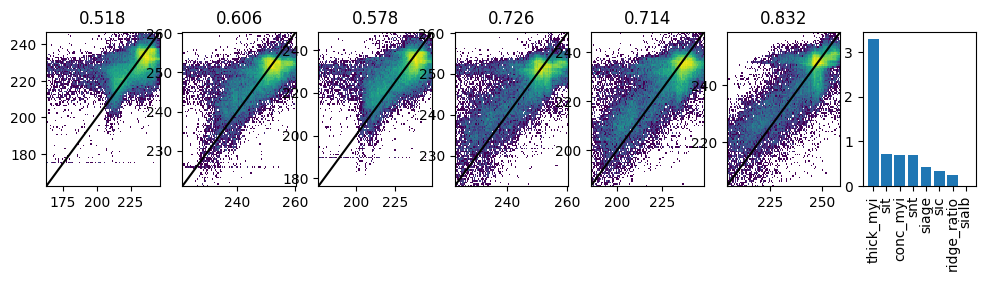

/tmp/ipykernel_401056/4266245481.py:96: RuntimeWarning: invalid value encountered in cast
  bands_pred_sca = np.clip(255 * (0.6 + (bands_pred - bands_avg[None][None]) / bands_std[None][None] / 4), 0, 255).astype('uint8')


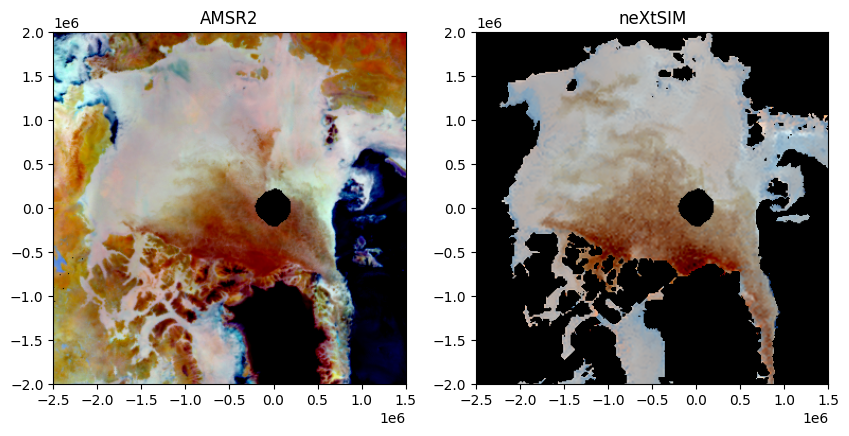

In [27]:
for YEAR in range(2013, 2022):
    amsr2_file = f'{amsr2_dir}/AMSR_U2_L3_SeaIce12km_B04_{YEAR}0101.he5'
    with xa.open_dataset(amsr2_file, group='HDFEOS/GRIDS/NpPolarGrid12km/Data Fields') as ds:
        bands = np.dstack([ds[band_name].to_numpy() for band_name in band_names])
        amsr2_sic = ds['SI_12km_NH_ICECON_ASC'].to_numpy()

    with xa.open_dataset(amsr2_file, group='HDFEOS/GRIDS/NpPolarGrid12km') as ds:
        lon = ds.lon.to_numpy()
        lat = ds.lat.to_numpy()

    gpi = np.isfinite(bands[:,:,0]) * (amsr2_sic > 15) * (amsr2_sic <= 100)
    bands_gpi = bands[gpi, :]

    bands_avg = bands_gpi.mean(axis=0)
    bands_std = bands_gpi.std(axis=0)
    bands_sca = np.clip(255 * (0.6 + (bands - bands_avg[None][None]) / bands_std[None][None] / 4), 0, 255).astype('uint8')

    nex_file = f'/data2/antonk/nextsim_paper/Moorings_{YEAR}m01.nc'
    with xa.open_dataset(nex_file) as ds:
        data = {name: ds[name][0].to_numpy() for name in titles}
        nlat = ds.latitude.to_numpy()
        nlon = ds.longitude.to_numpy()
    data['mask'] = np.isnan(data['sit'])
    data['mask'][0] = True
    data['mask'][-1] = True
    data['mask'][:, 0] = True
    data['mask'][:, -1] = True

    proj = ccrs.NorthPolarStereo(true_scale_latitude=60, central_longitude=-45)
    amsr_x, amsr_y, _ = proj.transform_points(ccrs.PlateCarree(), lon, lat).T
    amsr_x, amsr_y = amsr_x.T, amsr_y.T
    n_xy = proj.transform_points(ccrs.PlateCarree(), nlon, nlat)
    n_x = n_xy[0,:,0]
    n_y = n_xy[:,0,1]

    amsr_data = {}
    for name in titles_plus + ['mask']:
        data[name] = np.where(np.isnan(data[name]), 0, data[name])
        s = RectBivariateSpline(n_y, n_x, data[name])
        amsr_data[name] = s(amsr_y, amsr_x, grid=False)

    #r0, r1 = 300, 700
    #c0, c1 = 100, 400
    #fig, axs = plt.subplots(2, 4, figsize=(8,4), sharex=True, sharey=True)
    #axs.flat[0].imshow(bands_sca[r0:r1, c0:c1, [0,3,5]])
    #for i, name in enumerate(imshow_names):
    #    axs.flat[i+1].imshow(amsr_data[name][r0:r1, c0:c1])
    #plt.show()

    for name in titles_plus:
        if name != 'mask':
            amsr_data[name][amsr_data['mask'] > 0.1] = 0
            amsr_data[name][amsr_data[name] < 0.01] = 0

    cube = np.dstack([bands, np.dstack([amsr_data[name] for name in titles_plus])])
    gpi = np.isfinite(cube[:,:,0]) * (cube[:, :, 12] < 0.5) * (amsr2_sic > 50) * (amsr2_sic <= 100) * (amsr_data['mask'] < 0.1)
    cube_gpi = cube[gpi, :]

    A = np.vstack(
        [cube_gpi[:, i] for i in range(len(band_names), len(band_names) + len(titles_plus))] +
        [np.ones_like(cube_gpi[:, 0])]
    ).T

    BB = {}
    bands_pred = np.array(bands) + np.nan
    band_rmse_rnds = []
    fig, axs = plt.subplots(1, 7, figsize=(12,2))
    for i, band_no in enumerate([0, 1, 2, 3, 4, 5]):
        B = np.linalg.lstsq(A, cube_gpi[:, band_no])[0]
        BB[band_no] = B
        Y = np.dot(A, B)
        bands_pred[gpi, band_no] = Y.flatten()
        r = pearsonr(Y, cube_gpi[:, band_no])[0]
        rmse = ((Y - cube_gpi[:, band_no])**2).mean()**0.5

        rmse_rnds = []
        for var_num in range(0, len(titles_plus)):
            Arnd = np.array(A)
            Arnd[:,var_num] = np.random.permutation(A[:,var_num])
            Y_rnd = np.dot(Arnd, B)
            rmse_rnd = ((Y_rnd - cube_gpi[:, band_no])**2).mean()**0.5
            rmse_rnds.append(rmse_rnd - rmse)
        band_rmse_rnds.append(rmse_rnds)

        lims = np.percentile(cube_gpi[:, band_no], [1, 99])
        axs[i].hist2d(cube_gpi[:, band_no], Y, 100, [lims, lims], cmin=1, norm=LogNorm())
        axs[i].plot(lims, lims, 'k-')
        axs[i].set_title(f'{r:0.3}')

    rmse_rnds_avg = np.array(band_rmse_rnds).mean(axis=0)
    rmse_rnds_avg_idx = np.argsort(rmse_rnds_avg)[::-1]
    axs[6].bar(np.array(titles_plus)[rmse_rnds_avg_idx], rmse_rnds_avg[rmse_rnds_avg_idx])
    axs[6].tick_params(axis='x', labelrotation=90)
    plt.show()

    bands_pred_sca = np.clip(255 * (0.6 + (bands_pred - bands_avg[None][None]) / bands_std[None][None] / 4), 0, 255).astype('uint8')
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(bands_sca[:,:,[0,3,5]], extent=[amsr_x.min(), amsr_x.max(), amsr_y.min(), amsr_y.max()])
    axs[1].imshow(bands_pred_sca[:,:,[0,3,5]], extent=[amsr_x.min(), amsr_x.max(), amsr_y.min(), amsr_y.max()])
    #axs[2].imshow(bands_pred[:,:,0] - cube[:,:,0], extent=[amsr_x.min(), amsr_x.max(), amsr_y.min(), amsr_y.max()], clim=[-70, 70], cmap='coolwarm')
    axs[0].set_title('AMSR2')
    axs[1].set_title('neXtSIM')
    for ax in axs:
        ax.set_xlim([-2.5e6, 1.5e6])
        ax.set_ylim([-2e6, 2e6])
    plt.show()
    break


0 12.98376377106862
1 6.0870819025391505
2 11.355585818952784
3 5.844693663975055
4 10.426837711855478
5 6.802973532543066


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'thick_myi'),
  Text(1, 0, 'sit'),
  Text(2, 0, 'conc_myi'),
  Text(3, 0, 'snt'),
  Text(4, 0, 'siage'),
  Text(5, 0, 'sic'),
  Text(6, 0, 'ridge_ratio'),
  Text(7, 0, 'sialb')])

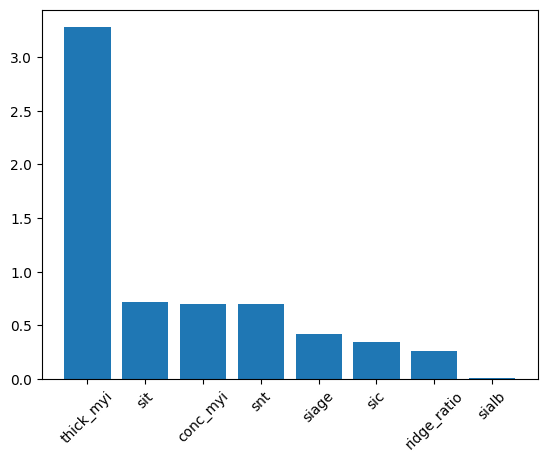